In [3]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import os

In [77]:
dataset = "mnist"

In [88]:
# Load the data

z_data = np.load(os.path.join(dataset,'all_val_z.npy'))

# Inspect the shape of the data
z_data.shape
# Calculate the mean and variance along the 0-axis (across the samples for each feature)
z_mean = np.mean(z_data, axis=0)
z_var = np.var(z_data, axis=0)

In [89]:
z_var

array([2.7442138 , 0.01121995, 2.4253156 , 2.757213  , 2.4929926 ,
       2.6058574 , 2.3842523 , 2.4506376 , 2.4194877 , 2.4272268 ,
       3.068135  , 2.4512427 , 2.9893246 , 2.947808  , 2.7898269 ,
       2.460845  , 2.4503343 , 2.7541006 , 2.5150466 , 2.4736495 ,
       2.8486197 , 2.8841555 , 2.724045  , 2.9970891 , 2.8088956 ,
       2.8915029 , 2.4727905 , 2.8675048 , 2.9108138 , 2.527579  ,
       2.5949304 , 2.463416  , 2.453729  , 2.403391  , 2.949927  ,
       2.6162753 , 2.4310317 , 3.0498333 , 2.979918  , 2.8322191 ,
       2.4752266 , 2.4081542 , 2.3823292 , 2.3621044 , 3.0555017 ,
       2.3956063 , 2.387164  , 2.6117022 , 3.0612872 , 3.0909894 ,
       2.4493396 , 2.4370124 , 2.5523496 , 2.4674408 , 2.3709896 ,
       2.9767969 , 2.952249  , 2.4516892 , 2.6014216 , 2.4269505 ,
       2.4303381 , 2.446477  , 2.5142877 , 2.4076958 , 2.4651134 ,
       2.646423  , 2.4927266 , 2.5228822 , 2.4189262 , 2.923656  ,
       2.4609225 , 2.4423175 , 2.4517148 , 2.4455044 , 2.42647

In [90]:
z_mean.shape

(256,)

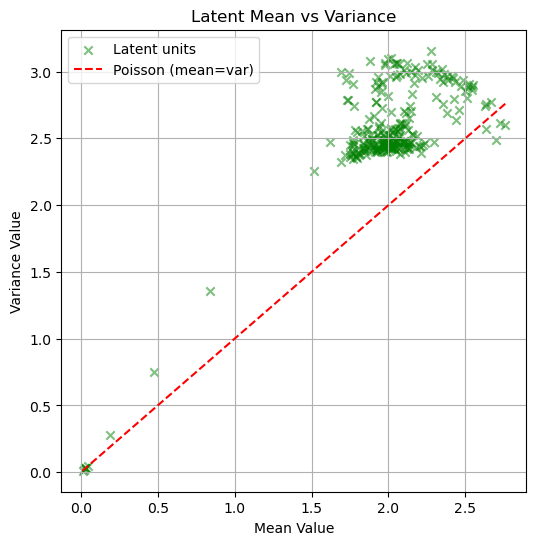

<Figure size 640x480 with 0 Axes>

In [91]:
plt.figure(figsize=(6, 6))
plt.scatter(z_mean, z_var, alpha=0.5, color='green',label='Latent units',marker='x')
plt.plot([min(z_mean), max(z_mean)], [min(z_mean), max(z_mean)], color='red', linestyle='--', label='Poisson (mean=var)')

# Set equal scaling for both axes
# plt.axis('equal')
# plt.xlim(0.55, max(z_mean))
plt.title('Latent Mean vs Variance')
plt.xlabel('Mean Value')
plt.ylabel('Variance Value')
plt.legend()
# plt.xlim(0.6)

plt.grid(True)
plt.show()
plt.tight_layout()
# fig.savefig("mean_var.pdf")

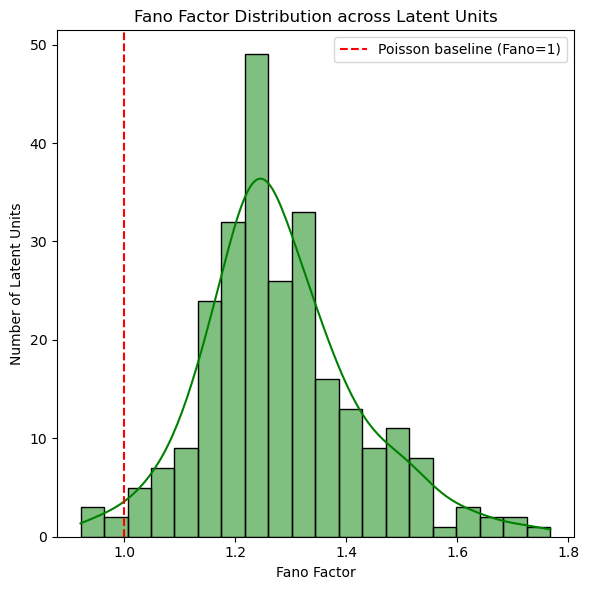

In [92]:
fano_factors = z_var / (z_mean + 1e-8)

fano_fig = plt.figure(figsize=(6, 6))
sns.histplot(fano_factors, bins=20, kde=True, color='green')
plt.axvline(1.0, color='red', linestyle='--', label='Poisson baseline (Fano=1)')
plt.title('Fano Factor Distribution across Latent Units')
plt.xlabel('Fano Factor')
plt.ylabel('Number of Latent Units')
plt.legend()
plt.tight_layout()